スペクトログラム＆フォルマント周波数の波形出力

In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import lfilter
import soundfile as sf
import os

# ==========================================
# 1. 設定：比較したい2つの音声ファイル名
# ==========================================
files = {
    'harusu': 'nanishi_150_harusu_150_20260608_113724.wav',
    # 💡もう1つの「はるの」のファイル名（113650など）をここに正確に書いてください
    'haruno': 'nanishi_haruno_20260517_180128.wav' 
}

# フォルマント抽出用の内部関数（廣瀬さんのコードを移植）
def estimate_formants(y, sr):
    y_filt = lfilter([1, -0.63], [1], y)
    frame_length = int(0.025 * sr)
    hop_length = int(0.010 * sr)
    frames = librosa.util.frame(y_filt, frame_length=frame_length, hop_length=hop_length)
    f1_list, f2_list = [], []
    for frame in frames.T:
        windowed = frame * np.hamming(len(frame))
        a = librosa.lpc(windowed, order=18)
        roots = np.roots(a)
        roots = [r for r in roots if np.imag(r) >= 0]
        ang = np.arctan2(np.imag(roots), np.real(roots))
        frqs = sorted(ang * (sr / (2 * np.pi)))
        formants = [f for f in frqs if 250 < f < 3500]
        f1_list.append(formants[0] if len(formants) > 0 else 0)
        f2_list.append(formants[1] if len(formants) > 1 else 0)
    return np.array(f1_list), np.array(f2_list), hop_length

# ==========================================
# 2. メイン処理：位置合わせと全画像の一括生成
# ==========================================
for label, file_name in files.items():
    if not os.path.exists(file_name):
        print(f"【警告】ファイルが見つかりません: {file_name} (スキップします)")
        continue
        
    print(f"\n🎬 {file_name} の処理を開始します...")
    
    # ─── A. 音声の読み込みと自動位置合わせ ───
    # フォルマント計算の精度向上のため、16kHzリサンプリングで統一して読み込みます
    y_raw, sr = librosa.load(file_name, sr=16000)
    
    # 20dB以上の音（声の始まり）を検知して頭の無音を自動カット
    y_trimmed, index = librosa.effects.trim(y_raw, top_db=20)
    print(f" └ 前方の無音を {index[0]/sr:.2f} 秒カットして位置を揃えました。")
    
    # ─── B. 波形（Waveform）の生成と保存 ───
    plt.figure(figsize=(10, 3))
    librosa.display.waveshow(y_trimmed, sr=sr, color="blue")
    plt.title(f'Waveform - Aligned ({label})')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    
    wave_img_name = f'なにし_{label}.png'
    plt.savefig(wave_img_name)
    plt.close()
    print(f" └ 💾 保存完了: {wave_img_name}")
    
    # ─── C. スペクトログラム ＆ フォルマントの計算 ───
    D = librosa.stft(y_trimmed)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    
    f1, f2, hop = estimate_formants(y_trimmed, sr)
    times = librosa.frames_to_time(range(len(f1)), sr=sr, hop_length=hop)
    
    # ─── D. フォルマント付スペクトログラムの生成と保存 ───
    plt.figure(figsize=(10, 5))
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
    
    # フォルマント（F1:赤, F2:水色）を重ね書き
    plt.plot(times[f1>0], f1[f1>0], label='F1 (First Formant)', color='red', linewidth=2)
    plt.plot(times[f2>0], f2[f2>0], label='F2 (Second Formant)', color='cyan', linewidth=2)
    
    plt.ylim(0, 4000)  # 人間の声の主要帯域にズーム
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Spectrogram with Formants - Aligned ({label})')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.legend(loc='upper right')
    plt.tight_layout()
    
    formant_img_name = f'なにし_{label}_F.png'
    plt.savefig(formant_img_name)
    plt.close()
    print(f" └ 💾 保存完了: {formant_img_name}")

print("\n✨ すべての画像が、スタート位置ピッタリの状態で保存されました！ ✨")


🎬 nanishi_150_harusu_150_20260608_113724.wav の処理を開始します...
 └ 前方の無音を 1.38 秒カットして位置を揃えました。
 └ 💾 保存完了: なにし_harusu.png
 └ 💾 保存完了: なにし_harusu_F.png

🎬 nanishi_haruno_20260517_180128.wav の処理を開始します...
 └ 前方の無音を 9.76 秒カットして位置を揃えました。
 └ 💾 保存完了: なにし_haruno.png
 └ 💾 保存完了: なにし_haruno_F.png

✨ すべての画像が、スタート位置ピッタリの状態で保存されました！ ✨


波形比較

📊 【波形のみの検証結果】境界線: 1.3秒
 🔹 前半（『なにし』部分）の一致率 : 0.03 %
 🔹 後半（上の句分岐部分）の一致率 : 0.04 %


c:\Users\misak\Desktop\karuta_vosk\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\misak\Desktop\karuta_vosk\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12395 (\N{HIRAGANA LETTER NI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\misak\Desktop\karuta_vosk\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12375 (\N{HIRAGANA LETTER SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\misak\Desktop\karuta_vosk\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32066 (\N{CJK UNIFIED IDEOGRAPH-7D42}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\misak\Desktop\karuta_vosk\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20102 (\N{CJK 

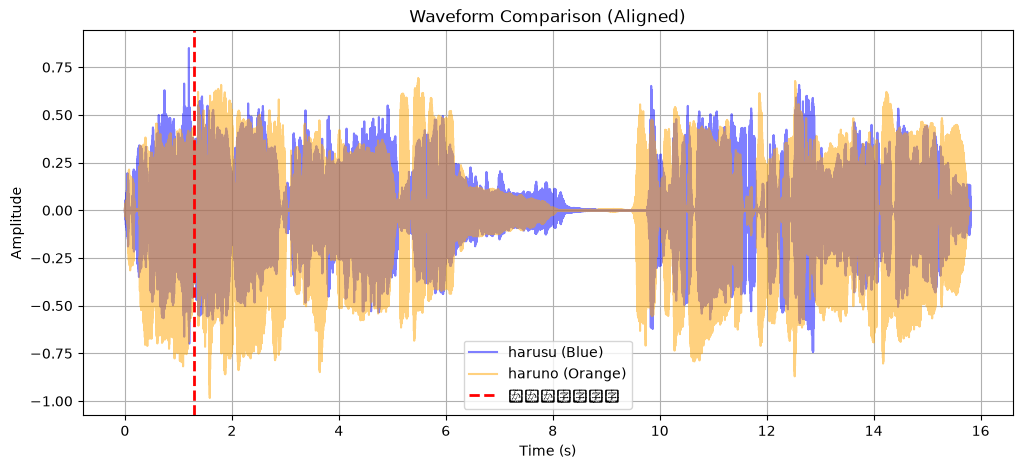

In [18]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 音声ファイルの指定と読み込み
# ==========================================
file_harusu = 'nanishi_150_harusu_150_20260608_113724.wav'
file_haruno = 'nanishi_haruno_20260517_180128.wav'

# モノラルで確実に読み込む
y1, sr = librosa.load(file_harusu, sr=16000, mono=True)
y2, _  = librosa.load(file_haruno, sr=16000, mono=True)

# ==========================================
# 2. 自動で頭合わせ（声が出た瞬間を0秒にする）
# ==========================================
w1_trimmed, index1 = librosa.effects.trim(y1, top_db=20)
w2_trimmed, index2 = librosa.effects.trim(y2, top_db=20)

# 2つの音声の長さを短い方に揃える（単純なカット）
min_len = min(len(w1_trimmed), len(w2_trimmed))
w1 = w1_trimmed[:min_len]
w2 = w2_trimmed[:min_len]

# ==========================================
# 💡 3. 一致率（類似度）の計算
# ==========================================
# 「なにし」が終了する秒数をここで仮設定（グラフを見て後で調整します）
border_time = 1.3 
idx_border = int(border_time * sr)

def calc_wave_similarity(v1, v2):
    # コサイン類似度：ベクトルの向き（波の形のパターンの似具合）を-100%〜100%で出す
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 == 0 or n2 == 0: return 0
    return (np.dot(v1, v2) / (n1 * n2)) * 100

sim_zenhan = calc_wave_similarity(w1[:idx_border], w2[:idx_border])
sim_kouhan = calc_wave_similarity(w1[idx_border:], w2[idx_border:])

print("==================================================")
print(f"📊 【波形のみの検証結果】境界線: {border_time}秒")
print("==================================================")
print(f" 🔹 前半（『なにし』部分）の一致率 : {sim_zenhan:.2f} %")
print(f" 🔹 後半（上の句分岐部分）の一致率 : {sim_kouhan:.2f} %")
print("==================================================")

# ==========================================
# 📊 4. グラフを画面に出して目視確認
# ==========================================
plt.figure(figsize=(12, 5))
times = np.linspace(0, min_len / sr, min_len)

# 2つの波形を半透明（alpha=0.5）にして重ね合わせる
plt.plot(times, w1, label='harusu (Blue)', color='blue', alpha=0.5)
plt.plot(times, w2, label='haruno (Orange)', color='orange', alpha=0.5)

# 境界線を赤い点線で引く
plt.axvline(x=border_time, color='red', linestyle='--', linewidth=2, label='なにし終了位置')

plt.title('Waveform Comparison (Aligned)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

📊 【MFCC（音の成分）検証結果】境界線: 3.2秒
 🌟 前半（『なにし』部分）のMFCC一致率 : 61.19 %
 🌟 後半（『上の句』部分）のMFCC一致率 : 80.73 %


C:\Users\misak\AppData\Local\Temp\ipykernel_15380\2985769254.py:79: UserWarning: Glyph 127756 (\N{MILKY WAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_15380\2985769254.py:79: UserWarning: Glyph 38899 (\N{CJK UNIFIED IDEOGRAPH-97F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_15380\2985769254.py:79: UserWarning: Glyph 22768 (\N{CJK UNIFIED IDEOGRAPH-58F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_15380\2985769254.py:79: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_15380\2985769254.py:79: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_15380\2985769254.py:79: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing f

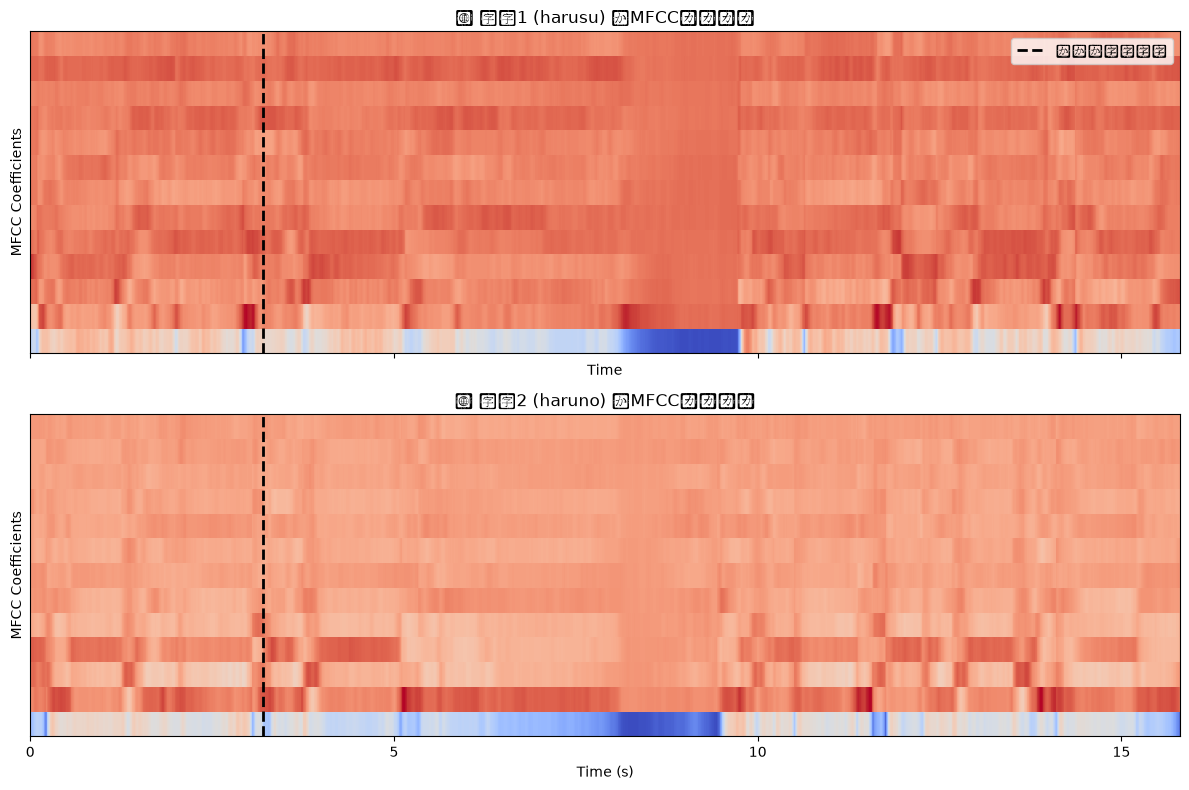

In [19]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 音声ファイルの読み込みと頭合わせ
# ==========================================
file_harusu = 'nanishi_150_harusu_150_20260608_113724.wav'
file_haruno = 'nanishi_haruno_20260517_180128.wav'

# モノラルで確実に読み込む
y1, sr = librosa.load(file_harusu, sr=16000, mono=True)
y2, _  = librosa.load(file_haruno, sr=16000, mono=True)

# 声が出た瞬間を検知して頭合わせ
w1_trimmed, _ = librosa.effects.trim(y1, top_db=20)
w2_trimmed, _ = librosa.effects.trim(y2, top_db=20)

# ==========================================
# 💡 2. 音声認識の指針「MFCC」をその場で抽出
# ==========================================
# n_mfcc=13 は音声認識（Voskなど）で最も標準的な設定です
# これにより、母音（口の形）も子音（ノイズ）も13個の数字のセットに濃縮されます
mfcc1 = librosa.feature.mfcc(y=w1_trimmed, sr=sr, n_mfcc=13, hop_length=160)
mfcc2 = librosa.feature.mfcc(y=w2_trimmed, sr=sr, n_mfcc=13, hop_length=160)

# 2つのMFCCデータのフレーム数（時間）を短い方に合わせる
min_frames = min(mfcc1.shape[1], mfcc2.shape[1])
m1 = mfcc1[:, :min_frames]
m2 = mfcc2[:, :min_frames]

# ==========================================
# 📈 3. MFCCベースでの正確な一致率計算
# ==========================================
# 波形グラフの見た目から、「なにし」が終わる位置を3.2秒付近と仮定
border_time = 3.2 
# hop_length=160 (10ms) ごとに1フレーム進むので、秒数からフレーム位置を計算
idx_border = int(border_time * (sr / 160))

def calc_mfcc_similarity(matrix1, matrix2):
    # 2次元のMFCCデータを1次元に平坦化して、純粋な「音の成分パターン」のコサイン類似度を計算
    v1 = matrix1.flatten()
    v2 = matrix2.flatten()
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 == 0 or n2 == 0: return 0
    return (np.dot(v1, v2) / (n1 * n2)) * 100

sim_zenhan = calc_mfcc_similarity(m1[:, :idx_border], m2[:, :idx_border])
sim_kouhan = calc_mfcc_similarity(m1[:, idx_border:], m2[:, idx_border:])

print("==================================================")
print(f"📊 【MFCC（音の成分）検証結果】境界線: {border_time}秒")
print("==================================================")
print(f" 🌟 前半（『なにし』部分）のMFCC一致率 : {sim_zenhan:.2f} %")
print(f" 🌟 後半（『上の句』部分）のMFCC一致率 : {sim_kouhan:.2f} %")
print("==================================================")

# ==========================================
# 📊 4. 視覚的根拠：MFCC（音声認識の目）の並列比較グラフ
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
times = np.linspace(0, min_frames * 160 / sr, min_frames)

# 音声1のMFCC（音の成分パターン）を可視化
img1 = librosa.display.specshow(m1, sr=sr, hop_length=160, x_axis='time', ax=ax1, cmap='coolwarm')
ax1.axvline(x=border_time, color='black', linestyle='--', linewidth=2, label='なにし終了位置')
ax1.set_title('🌌 音声1 (harusu) のMFCCパターン')
ax1.set_ylabel('MFCC Coefficients')
ax1.legend()

# 音声2のMFCC（音の成分パターン）を可視化
img2 = librosa.display.specshow(m2, sr=sr, hop_length=160, x_axis='time', ax=ax2, cmap='coolwarm')
ax2.axvline(x=border_time, color='black', linestyle='--', linewidth=2)
ax2.set_title('🌌 音声2 (haruno) のMFCCパターン')
ax2.set_ylabel('MFCC Coefficients')
ax2.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

音声録音プログラム

In [30]:
import os
import sys
import time
import wave
import numpy as np
import sounddevice as sd

# ==========================================
# ⚙️ 設定エリア
# ==========================================
TARGET_DIR = "karuta_database"  # 保存する親フォルダ名
RECORD_PART = 1  # 録音のパート番号（末尾に _1 がつきます）

START_NUM = 1  # 開始する札番号
END_NUM = 100  # 終了する札番号

# 🎙️ 録音の感度設定
RMS_THRESHOLD = 0.004  # この音量を下回ったら「無音」とみなす
SILENCE_DURATION = 1.0  # 何秒間無音が続いたら「句の切れ目」とするか

# 音声の設定
RATE = 16000  # 16kHz（音声解析の標準）
CHANNELS = 1
CHUNK_SIZE = 1024  # 1回に読み込む音声の塊のサイズ

os.makedirs(TARGET_DIR, exist_ok=True)


def draw_volume_bar(rms, threshold, is_recording=False):
    """コンソール上にリアルタイムの音量メーターを描画する関数"""
    bar_length = 30
    filled_length = int(round(bar_length * min(rms, 0.1) / 0.1))

    status = "🔴 REC" if is_recording else "⏳ WAIT"
    bar = "■" * filled_length + "-" * (bar_length - filled_length)

    thresh_pos = int(round(bar_length * min(threshold, 0.1) / 0.1))
    bar_list = list(bar)
    if thresh_pos < len(bar_list):
        bar_list[thresh_pos] = "｜"
    bar = "".join(bar_list)

    sys.stdout.write(f"\r{status} [{bar}] RMS: {rms:.4f} ")
    sys.stdout.flush()


def record_phrase(card_num, part_type):
    """1つの句をsounddeviceで録音する関数"""
    part_name = (
        f"上の句 (u) [__{RECORD_PART}]"
        if part_type == "u"
        else f"下の句 (s) [__{RECORD_PART}]"
    )
    print(f"\n==================================================")
    print(f" 🎯 札番号【{card_num:03d}】の【{part_name}】待機中...")
    print(f"==================================================")

    frames = []
    is_speaking = False
    silence_start_time = None

    # 💡 sounddeviceのInputStreamを立ち上げます
    with sd.InputStream(
        samplerate=RATE, channels=CHANNELS, dtype="int16", blocksize=CHUNK_SIZE
    ) as stream:
        while True:
            # 音声データをCHUNK_SIZE分だけ読み込む
            data, overflow = stream.read(CHUNK_SIZE)
            frames.append(data.copy())

            # 音量（RMS）の計算
            audio_data = data.flatten().astype(np.float32)
            rms = np.sqrt(np.mean((audio_data / 32768.0) ** 2))

            # メーターの描画
            draw_volume_bar(rms, RMS_THRESHOLD, is_speaking)

            # 音声の開始検知
            if not is_speaking and rms > RMS_THRESHOLD:
                is_speaking = True
                frames = frames[-15:]  # 発声直前の音を少し残す

            # 音声の終了検知
            if is_speaking:
                if rms < RMS_THRESHOLD:
                    if silence_start_time is None:
                        silence_start_time = time.time()
                    elif time.time() - silence_start_time > SILENCE_DURATION:
                        print(f"\n🛑 [終了] 静寂を検知しました。")
                        break
                else:
                    silence_start_time = None

    # 全フレームを1つのデータに結合
    audio_buffer = np.concatenate(frames, axis=0)

    # ファイル名の決定
    filename = f"{card_num:03d}_{part_type}_{RECORD_PART}.wav"
    full_filename = os.path.join(TARGET_DIR, filename)

    # WAVファイルとして保存
    wf = wave.open(full_filename, "wb")
    wf.setnchannels(CHANNELS)
    wf.setsampwidth(2)  # 16-bit は 2 bytes
    wf.setframerate(RATE)
    wf.writeframes(audio_buffer.tobytes())
    wf.close()

    print(f"💾 保存完了: {full_filename}")


# ==========================================
# 🎬 メインループ
# ==========================================
try:
    for card_idx in range(START_NUM, END_NUM + 1):
        record_phrase(card_idx, "u")
        time.sleep(1)

        record_phrase(card_idx, "s")
        time.sleep(2)

    print("\n==================================================")
    print(f"🎉 すべての録音（パート {RECORD_PART}）が終了しました！")
    print("==================================================")

except KeyboardInterrupt:
    print("\n👋 途中で録音を停止しました。")


 🎯 札番号【001】の【上の句 (u) [__1]】待機中...
🔴 REC [-｜----------------------------] RMS: 0.0003 
🛑 [終了] 静寂を検知しました。
💾 保存完了: karuta_database\001_u_1.wav

 🎯 札番号【001】の【下の句 (s) [__1]】待機中...
🔴 REC [-｜----------------------------] RMS: 0.0003 
🛑 [終了] 静寂を検知しました。
💾 保存完了: karuta_database\001_s_1.wav

 🎯 札番号【002】の【上の句 (u) [__1]】待機中...
🔴 REC [-｜----------------------------] RMS: 0.0004 
🛑 [終了] 静寂を検知しました。
💾 保存完了: karuta_database\002_u_1.wav

 🎯 札番号【002】の【下の句 (s) [__1]】待機中...
🔴 REC [-｜----------------------------] RMS: 0.0004 
🛑 [終了] 静寂を検知しました。
💾 保存完了: karuta_database\002_s_1.wav

 🎯 札番号【003】の【上の句 (u) [__1]】待機中...
🔴 REC [-｜----------------------------] RMS: 0.0005 
🛑 [終了] 静寂を検知しました。
💾 保存完了: karuta_database\003_u_1.wav

 🎯 札番号【003】の【下の句 (s) [__1]】待機中...
🔴 REC [-｜----------------------------] RMS: 0.0013 
🛑 [終了] 静寂を検知しました。
💾 保存完了: karuta_database\003_s_1.wav

 🎯 札番号【004】の【上の句 (u) [__1]】待機中...
🔴 REC [-｜----------------------------] RMS: 0.0010 
🛑 [終了] 静寂を検知しました。
💾 保存完了: karuta_database\004_u_1.wav

 🎯 札番号【004】の

In [1]:
import glob
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# ⚙️ 設定エリア
# ==========================================
TARGET_DIR = "karuta_database"  # 録音データが入っているフォルダ
RECORD_PART = 1  # 表示したいパート番号

# 1番から100番までのファイルをきれいに並べるための準備
print("🔍 音声ファイルを読み込んでいます...")

plt.figure(figsize=(20, 40))  # 縦に長い特大のグラフを作成（100首分）

# 1番から100番まで順番に処理
plot_idx = 1
for card_idx in range(1, 101):
    for part_type in ["u", "s"]:  # 上の句(u) -> 下の句(s) の順
        filename = f"{card_idx:03d}_{part_type}_{RECORD_PART}.wav"
        file_path = os.path.join(TARGET_DIR, filename)

        # ファイルが存在する場合だけグラフに描画
        if os.path.exists(file_path):
            # 音声ファイルの読み込み
            y, sr = librosa.load(file_path, sr=16000, mono=True)

            # 100首×2（上下）＝最大200個のミニグラフを縦に並べる
            # 50行 × 4列 の構成で綺麗に並べます
            plt.subplot(50, 4, plot_idx)

            # 波形を描画（薄い青色）
            times = np.linspace(0, len(y) / sr, len(y))
            plt.plot(times, y, color="blue", alpha=0.6, linewidth=0.5)

            # グラフの見た目をシンプルに整える
            part_title = "上の句" if part_type == "u" else "下の句"
            plt.title(f"{card_idx:03d} {part_title}", fontsize=10)
            plt.ylim(-1.0, 1.0)
            plt.grid(True, alpha=0.3)

            # 横軸（秒数）と縦軸のラベルは小さく
            plt.tick_params(labelsize=8)

            plot_idx += 1

plt.tight_layout()

# 💡 画像ファイルとして保存（画面に表示するだけでなく、じっくり見られるように）
output_img = "all_waveforms_result.png"
plt.savefig(output_img, dpi=150)
plt.close()

print("==================================================")
print(f"🎉 完了しました！")
print(f"📁 保存先: {os.path.abspath(output_img)}")
print("==================================================")
print("この画像を開くと、1番から100番までの波形が図鑑のようにズラッと並んでいます。")

🔍 音声ファイルを読み込んでいます...


C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3288057013.py:50: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3288057013.py:50: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3288057013.py:50: UserWarning: Glyph 21477 (\N{CJK UNIFIED IDEOGRAPH-53E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3288057013.py:50: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3288057013.py:54: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.savefig(output_img, dpi=150)
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3288057013.py:54: UserWarning: Glyph 12

🎉 完了しました！
📁 保存先: c:\Users\misak\Desktop\karuta_vosk\all_waveforms_result.png
この画像を開くと、1番から100番までの波形が図鑑のようにズラッと並んでいます。


In [3]:
import os
import glob
import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ==========================================
# ⚙️ 設定エリア
# ==========================================
TARGET_DIR = "karuta_database"  # 録音データが入っているフォルダ
RECORD_PART = 1
N_CLUSTERS = 3  # 上の句・下の句それぞれを何グループに分けるか（各3枚、計6枚の画像になります）

# ==========================================
# 1. 音声データの読み込み（最初から上下を分ける）
# ==========================================
print("🔍 音声データを「上の句」「下の句」に分けて分析中...")

data_u = []  # 上の句用のデータリスト
data_s = []  # 下の句用のデータリスト

features_u = []  # 上の句の特徴量
features_s = []  # 下の句の特徴量

for card_idx in range(1, 101):
    for part_type in ["u", "s"]:
        filename = f"{card_idx:03d}_{part_type}_{RECORD_PART}.wav"
        file_path = os.path.join(TARGET_DIR, filename)
        
        if os.path.exists(file_path):
            # 音声の読み込みとMFCC抽出
            y, sr = librosa.load(file_path, sr=16000, mono=True)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
            mfcc_mean = np.mean(mfcc, axis=1)
            
            info = {
                "label": f"{card_idx:03d}_{'上の句' if part_type=='u' else '下の句'}",
                "y": y,
                "sr": sr
            }
            
            if part_type == "u":
                data_u.append(info)
                features_u.append(mfcc_mean)
            else:
                data_s.append(info)
                features_s.append(mfcc_mean)

# ==========================================
# 2. グループ分けと画像保存を行う関数
# ==========================================
def cluster_and_plot(data_list, feature_list, part_title_en, part_title_jp):
    if len(feature_list) == 0:
        print(f"⚠️ {part_title_jp}のファイルが見つかりませんでした。")
        return
        
    X = np.array(feature_list)
    # 実際のファイル数がグループ数より少ない場合の安全対策
    clusters = min(N_CLUSTERS, len(X))
    
    kmeans = KMeans(n_clusters=clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    # グループごとに仕分け
    groups = {i: [] for i in range(clusters)}
    for idx, label in enumerate(labels):
        groups[label].append(data_list[idx])
        
    # 各グループをグラフ画像化
    for g_id, items in groups.items():
        if len(items) == 0: continue
        
        n_items = len(items)
        cols = 4
        rows = int(np.ceil(n_items / cols))
        
        # 上の句は「深みのある青」、下の句は「落ち着いた緑」で色分け
        plot_color = "midnightblue" if part_title_en == "kami" else "darkgreen"
        
        plt.figure(figsize=(16, rows * 3))
        for i, item in enumerate(items):
            plt.subplot(rows, cols, i + 1)
            times = np.linspace(0, len(item["y"]) / item["sr"], len(item["y"]))
            plt.plot(times, item["y"], color=plot_color, alpha=0.7, linewidth=0.6)
            
            plt.title(item["label"], fontsize=11, fontweight='bold')
            plt.ylim(-1.0, 1.0)
            plt.grid(True, alpha=0.3)
            plt.tick_params(labelsize=9)
            
        plt.tight_layout()
        
        # 💡 ファイル名に「kami（上の句）」か「shimo（下の句）」を明記
        output_name = f"similarity_{part_title_en}_group_{g_id + 1}.png"
        plt.savefig(output_name, dpi=120)
        plt.close()
        print(f" └ 💾 【{part_title_jp}】画像保存完了: {output_name}")

# ==========================================
# 3. 実行（上の句・下の句を完全に独立して処理）
# ==========================================
print("\n--- 🟥 上の句の分類を開始 ---")
cluster_and_plot(data_u, features_u, "kami", "上の句")

print("\n--- 🟩 下の下の句の分類を開始 ---")
cluster_and_plot(data_s, features_s, "shimo", "下の句")

print("\n==================================================")
print("🎉 修正完了！上下が完全に分かれた状態で、似てる順に整理されました。")
print("==================================================")

🔍 音声データを「上の句」「下の句」に分けて分析中...

--- 🟥 上の句の分類を開始 ---


C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3539126862.py:92: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3539126862.py:92: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3539126862.py:92: UserWarning: Glyph 21477 (\N{CJK UNIFIED IDEOGRAPH-53E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3539126862.py:96: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.savefig(output_name, dpi=120)
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3539126862.py:96: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.savefig(output_name, dpi=120)
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3539126862.py:96: UserWarning: 

 └ 💾 【上の句】画像保存完了: similarity_kami_group_1.png
 └ 💾 【上の句】画像保存完了: similarity_kami_group_2.png
 └ 💾 【上の句】画像保存完了: similarity_kami_group_3.png

--- 🟩 下の下の句の分類を開始 ---


C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3539126862.py:92: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3539126862.py:92: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3539126862.py:92: UserWarning: Glyph 21477 (\N{CJK UNIFIED IDEOGRAPH-53E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3539126862.py:96: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.savefig(output_name, dpi=120)
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3539126862.py:96: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.savefig(output_name, dpi=120)
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\3539126862.py:96: UserWarning: 

 └ 💾 【下の句】画像保存完了: similarity_shimo_group_1.png
 └ 💾 【下の句】画像保存完了: similarity_shimo_group_2.png
 └ 💾 【下の句】画像保存完了: similarity_shimo_group_3.png

🎉 修正完了！上下が完全に分かれた状態で、似てる順に整理されました。


MFCC

In [4]:
import os
import glob
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ==========================================
# ⚙️ 設定エリア
# ==========================================
TARGET_DIR = "karuta_database"  # 録音データが入っているフォルダ
RECORD_PART = 1
N_CLUSTERS = 3  # 上下の句それぞれを何グループに分けるか

# ==========================================
# 1. 音声データの読み込みとMFCCの抽出
# ==========================================
print("🔍 全歌のMFCC（音の成分パターン）を分析中...")

data_u = []
data_s = []
features_u = []
features_s = []

for card_idx in range(1, 101):
    for part_type in ["u", "s"]:
        filename = f"{card_idx:03d}_{part_type}_{RECORD_PART}.wav"
        file_path = os.path.join(TARGET_DIR, filename)
        
        if os.path.exists(file_path):
            y, sr = librosa.load(file_path, sr=16000, mono=True)
            
            # 💡 今回は表示用につぶさない生のMFCC（2次元データ）を取得
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, hop_length=160)
            
            # AIのグループ分け用には、時間の平均を取った特徴量を使用
            mfcc_mean = np.mean(mfcc, axis=1)
            
            info = {
                "label": f"{card_idx:03d}_{'上の句' if part_type=='u' else '下の句'}",
                "mfcc": mfcc,  # 生のMFCCパターンをそのまま保持
                "sr": sr
            }
            
            if part_type == "u":
                data_u.append(info)
                features_u.append(mfcc_mean)
            else:
                data_s.append(info)
                features_s.append(mfcc_mean)

# ==========================================
# 2. MFCCの模様をクラスタリングしてプロットする関数
# ==========================================
def cluster_and_plot_mfcc(data_list, feature_list, part_title_en, part_title_jp):
    if len(feature_list) == 0:
        print(f"⚠️ {part_title_jp}のファイルが見つかりませんでした。")
        return
        
    X = np.array(feature_list)
    clusters = min(N_CLUSTERS, len(X))
    
    kmeans = KMeans(n_clusters=clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    groups = {i: [] for i in range(clusters)}
    for idx, label in enumerate(labels):
        groups[label].append(data_list[idx])
        
    for g_id, items in groups.items():
        if len(items) == 0: continue
        
        n_items = len(items)
        cols = 4
        rows = int(np.ceil(n_items / cols))
        
        plt.figure(figsize=(16, rows * 3))
        for i, item in enumerate(items):
            plt.subplot(rows, cols, i + 1)
            
            # 💡 librosaを使ってMFCCの「音の成分模様」をカラフルに描画
            # coolwarmカラー（赤と青）を使うことで、成分の強弱がひと目でわかります
            librosa.display.specshow(item["mfcc"], sr=item["sr"], hop_length=160, x_axis='time', cmap='coolwarm')
            
            plt.title(item["label"], fontsize=11, fontweight='bold')
            plt.ylabel('MFCC')
            plt.tick_params(labelsize=8)
            
        plt.tight_layout()
        
        # 💡 ファイル名に「mfcc_」をつけて区別できるようにします
        output_name = f"mfcc_{part_title_en}_group_{g_id + 1}.png"
        plt.savefig(output_name, dpi=120)
        plt.close()
        print(f" └ 💾 【{part_title_jp} MFCC】画像保存完了: {output_name}")

# ==========================================
# 3. 実行
# ==========================================
print("\n--- 🟥 上の句のMFCC分析を開始 ---")
cluster_and_plot_mfcc(data_u, features_u, "kami", "上の句")

print("\n--- 🟩 下の下の句のMFCC分析を開始 ---")
cluster_and_plot_mfcc(data_s, features_s, "shimo", "下の句")

print("\n==================================================")
print("🎉 完了！AIが見ている『MFCCの模様そのもの』でグループ画像ができました。")
print("==================================================")

🔍 全歌のMFCC（音の成分パターン）を分析中...

--- 🟥 上の句のMFCC分析を開始 ---


C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1160791149.py:90: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1160791149.py:90: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1160791149.py:90: UserWarning: Glyph 21477 (\N{CJK UNIFIED IDEOGRAPH-53E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1160791149.py:94: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.savefig(output_name, dpi=120)
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1160791149.py:94: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.savefig(output_name, dpi=120)
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1160791149.py:94: UserWarning: 

 └ 💾 【上の句 MFCC】画像保存完了: mfcc_kami_group_1.png
 └ 💾 【上の句 MFCC】画像保存完了: mfcc_kami_group_2.png
 └ 💾 【上の句 MFCC】画像保存完了: mfcc_kami_group_3.png

--- 🟩 下の下の句のMFCC分析を開始 ---


C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1160791149.py:90: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1160791149.py:90: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1160791149.py:90: UserWarning: Glyph 21477 (\N{CJK UNIFIED IDEOGRAPH-53E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1160791149.py:94: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.savefig(output_name, dpi=120)
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1160791149.py:94: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.savefig(output_name, dpi=120)
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1160791149.py:94: UserWarning: 

 └ 💾 【下の句 MFCC】画像保存完了: mfcc_shimo_group_1.png
 └ 💾 【下の句 MFCC】画像保存完了: mfcc_shimo_group_2.png
 └ 💾 【下の句 MFCC】画像保存完了: mfcc_shimo_group_3.png

🎉 完了！AIが見ている『MFCCの模様そのもの』でグループ画像ができました。


In [5]:
import os
import glob
import numpy as np
import librosa
import matplotlib.pyplot as plt

# ==========================================
# ⚙️ 設定エリア
# ==========================================
TARGET_DIR = "karuta_database"  # 録音データが入っているフォルダ
RECORD_PART = 1
BASE_OUTPUT_DIR = "mfcc_4blocks_analysis"  # 親フォルダ名

# ==========================================
# 1. 音声データの読み込みと4大ブロックへの統合
# ==========================================
print("🔍 音声を読み込み、4つの大きな特徴（パワー・母音・声質・子音）に分類中...")

data_u = []
data_s = []

for card_idx in range(1, 101):
    for part_type in ["u", "s"]:
        filename = f"{card_idx:03d}_{part_type}_{RECORD_PART}.wav"
        file_path = os.path.join(TARGET_DIR, filename)
        
        if os.path.exists(file_path):
            y, sr = librosa.load(file_path, sr=16000, mono=True)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, hop_length=160)
            mfcc_mean = np.mean(mfcc, axis=1)
            
            # 13項目を4つの大きな意味ごとにグループ合算
            block_power = mfcc_mean[0]                              # 項目1: パワー
            block_vowel = np.mean(np.abs(mfcc_mean[1:5]))           # 項目2〜5: 母音・口の形
            block_voice = np.mean(np.abs(mfcc_mean[5:9]))           # 項目6〜9: 声質・喉のクセ
            block_consonant = np.mean(np.abs(mfcc_mean[9:13]))       # 項目10〜13: 子音・キレ
            
            info = {
                "label": f"{card_idx:03d}_{'上の句' if part_type=='u' else '下の句'}",
                "blocks": [block_power, block_vowel, block_voice, block_consonant],
                "y": y,
                "sr": sr
            }
            
            if part_type == "u":
                data_u.append(info)
            else:
                data_s.append(info)

# ==========================================
# 2. 各フォルダを作成して並び替え画像化する関数
# ==========================================
block_names = [
    "01_声のパワー",
    "02_母音と口の形",
    "03_喉のクセと声質",
    "04_子音のキレと息"
]

def analyze_by_4_blocks_with_folders(data_list, part_title_en, part_title_jp):
    if len(data_list) == 0:
        print(f"⚠️ {part_title_jp}のデータがありません。")
        return
        
    for b_idx, b_name in enumerate(block_names):
        # 💡 大項目ごとの専用サブフォルダを自動作成
        sub_folder_path = os.path.join(BASE_OUTPUT_DIR, b_name)
        os.makedirs(sub_folder_path, exist_ok=True)
        
        # その大項目の値が近い順（＝似ている順）にソート
        sorted_data = sorted(data_list, key=lambda x: x["blocks"][b_idx])
        
        n_items = len(sorted_data)
        cols = 5
        rows = int(np.ceil(n_items / cols))
        
        plt.figure(figsize=(18, rows * 2.5))
        
        for i, item in enumerate(sorted_data):
            plt.subplot(rows, cols, i + 1)
            
            times = np.linspace(0, len(item["y"]) / item["sr"], len(item["y"]))
            color_map = "mediumblue" if part_title_en == "kami" else "forestgreen"
            plt.plot(times, item["y"], color=color_map, alpha=0.7, linewidth=0.5)
            
            plt.title(f"{item['label']}\n(スコア: {item['blocks'][b_idx]:.2f})", fontsize=9)
            plt.ylim(-1.0, 1.0)
            plt.grid(True, alpha=0.2)
            plt.tick_params(labelsize=7)
            
        plt.tight_layout()
        
        # 💡 各専用フォルダの直下に保存
        output_name = os.path.join(sub_folder_path, f"{part_title_en}_{b_name}.png")
        plt.savefig(output_name, dpi=100)
        plt.close()
        print(f" └ 📁 フォルダ【{b_name}】内に【{part_title_jp}】画像を保存しました")

# ==========================================
# 3. 実行
# ==========================================
print("\n--- 🟥 上の句の4大ブロックフォルダ分類を開始 ---")
analyze_by_4_blocks_with_folders(data_u, "kami", "上の句")

print("\n--- 🟩 下の下の句の4大ブロックフォルダ分類を開始 ---")
analyze_by_4_blocks_with_folders(data_s, "shimo", "下の句")

print("\n==================================================")
print(f"🎉 完了しました！大項目ごとにフォルダにカチッと仕分けられました。")
print(f"📁 保存先: {os.path.abspath(BASE_OUTPUT_DIR)}")
print("==================================================")

🔍 音声を読み込み、4つの大きな特徴（パワー・母音・声質・子音）に分類中...

--- 🟥 上の句の4大ブロックフォルダ分類を開始 ---


C:\Users\misak\AppData\Local\Temp\ipykernel_19404\4003385067.py:91: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\4003385067.py:91: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\4003385067.py:91: UserWarning: Glyph 21477 (\N{CJK UNIFIED IDEOGRAPH-53E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\4003385067.py:91: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\4003385067.py:91: UserWarning: Glyph 12467 (\N{KATAKANA LETTER KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\4003385067.py:91: UserWarning: Glyph 12450 (\N{KATAKANA LETTER A}) mi

 └ 📁 フォルダ【01_声のパワー】内に【上の句】画像を保存しました
 └ 📁 フォルダ【02_母音と口の形】内に【上の句】画像を保存しました
 └ 📁 フォルダ【03_喉のクセと声質】内に【上の句】画像を保存しました
 └ 📁 フォルダ【04_子音のキレと息】内に【上の句】画像を保存しました

--- 🟩 下の下の句の4大ブロックフォルダ分類を開始 ---


C:\Users\misak\AppData\Local\Temp\ipykernel_19404\4003385067.py:91: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


 └ 📁 フォルダ【01_声のパワー】内に【下の句】画像を保存しました
 └ 📁 フォルダ【02_母音と口の形】内に【下の句】画像を保存しました
 └ 📁 フォルダ【03_喉のクセと声質】内に【下の句】画像を保存しました
 └ 📁 フォルダ【04_子音のキレと息】内に【下の句】画像を保存しました

🎉 完了しました！大項目ごとにフォルダにカチッと仕分けられました。
📁 保存先: c:\Users\misak\Desktop\karuta_vosk\mfcc_4blocks_analysis


In [6]:
import os
import glob
import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ==========================================
# ⚙️ 設定エリア
# ==========================================
TARGET_DIR = "karuta_database"  # 録音データが入っているフォルダ
RECORD_PART = 1
BASE_OUTPUT_DIR = "mfcc_4blocks_clusters"  # 新しい親フォルダ名
N_CLUSTERS = 21  # 各項目を何グループに分けるか

# ==========================================
# 1. 音声データの読み込みと4大ブロックへの統合
# ==========================================
print("🔍 音声を読み込み、パワー・母音・声質・子音の4つの特徴を抽出中...")

data_u = []
data_s = []

for card_idx in range(1, 101):
    for part_type in ["u", "s"]:
        filename = f"{card_idx:03d}_{part_type}_{RECORD_PART}.wav"
        file_path = os.path.join(TARGET_DIR, filename)
        
        if os.path.exists(file_path):
            y, sr = librosa.load(file_path, sr=16000, mono=True)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, hop_length=160)
            mfcc_mean = np.mean(mfcc, axis=1)
            
            # 4大項目のベースとなる数値を計算
            block_power = mfcc_mean[0]
            block_vowel = np.mean(np.abs(mfcc_mean[1:5]))
            block_voice = np.mean(np.abs(mfcc_mean[5:9]))
            block_consonant = np.mean(np.abs(mfcc_mean[9:13]))
            
            info = {
                "label": f"{card_idx:03d}_{'上の句' if part_type=='u' else '下の句'}",
                "blocks": [block_power, block_vowel, block_voice, block_consonant],
                "y": y,
                "sr": sr
            }
            
            if part_type == "u":
                data_u.append(info)
            else:
                data_s.append(info)

# ==========================================
# 2. 各項目内でさらに「似てる順」にグループ分けして画像化する関数
# ==========================================
block_names = [
    "01_声のパワー",
    "02_母音と口の形",
    "03_喉のクセと声質",
    "04_子音のキレと息"
]

def cluster_and_plot_4_blocks(data_list, part_title_en, part_title_jp):
    if len(data_list) == 0:
        print(f"⚠️ {part_title_jp}のデータがありません。")
        return
        
    for b_idx, b_name in enumerate(block_names):
        # この項目の数値（1次元データ）を取り出してAI（K-Means）に学習させる
        X = np.array([item["blocks"][b_idx] for item in data_list]).reshape(-1, 1)
        
        clusters = min(N_CLUSTERS, len(X))
        kmeans = KMeans(n_clusters=clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        
        # グループごとにデータを仕分け
        groups = {i: [] for i in range(clusters)}
        for idx, label in enumerate(labels):
            groups[label].append(data_list[idx])
            
        # グループごとにフォルダを作って画像保存
        for g_id, items in groups.items():
            if len(items) == 0: continue
            
            # 💡 大項目 ➔ グループ（類似度）の順でフォルダを自動作成
            sub_folder_path = os.path.join(BASE_OUTPUT_DIR, b_name, f"group_{g_id + 1}")
            os.makedirs(sub_folder_path, exist_ok=True)
            
            # グループ内はスコア順にきれいに並べる
            sorted_items = sorted(items, key=lambda x: x["blocks"][b_idx])
            
            n_items = len(sorted_items)
            cols = 4  # グループごとで数が絞られるので、4列で見やすく
            rows = int(np.ceil(n_items / cols))
            
            plt.figure(figsize=(16, rows * 2.8))
            for i, item in enumerate(sorted_items):
                plt.subplot(rows, cols, i + 1)
                
                times = np.linspace(0, len(item["y"]) / item["sr"], len(item["y"]))
                color_map = "mediumblue" if part_title_en == "kami" else "forestgreen"
                plt.plot(times, item["y"], color=color_map, alpha=0.7, linewidth=0.5)
                
                plt.title(f"{item['label']}\n(値: {item['blocks'][b_idx]:.2f})", fontsize=10)
                plt.ylim(-1.0, 1.0)
                plt.grid(True, alpha=0.2)
                plt.tick_params(labelsize=8)
                
            plt.tight_layout()
            
            # 保存
            output_name = os.path.join(sub_folder_path, f"{part_title_en}_group_{g_id + 1}.png")
            plt.savefig(output_name, dpi=110)
            plt.close()
            
        print(f" └ 📁 【{part_title_jp}】{b_name} を類似度ごとに3グループに分解しました")

# ==========================================
# 3. 実行
# ==========================================
print("\n--- 🟥 上の句の項目別・類似度グループ仕分けを開始 ---")
cluster_and_plot_4_blocks(data_u, "kami", "上の句")

print("\n--- 🟩 下の下の句の項目別・類似度グループ仕分けを開始 ---")
cluster_and_plot_4_blocks(data_s, "shimo", "下の句")

print("\n==================================================")
print(f"🎉 完了！4ステップそれぞれの中で、さらに似てるグループへ仕分けられました。")
print(f"📁 保存先: {os.path.abspath(BASE_OUTPUT_DIR)}")
print("==================================================")

🔍 音声を読み込み、パワー・母音・声質・子音の4つの特徴を抽出中...

--- 🟥 上の句の項目別・類似度グループ仕分けを開始 ---


C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:108: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:108: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:108: UserWarning: Glyph 21477 (\N{CJK UNIFIED IDEOGRAPH-53E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:108: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:112: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.savefig(output_name, dpi=110)
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:112: UserWarning: G

 └ 📁 【上の句】01_声のパワー を類似度ごとに3グループに分解しました


C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:108: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:108: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:108: UserWarning: Glyph 21477 (\N{CJK UNIFIED IDEOGRAPH-53E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:108: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:112: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.savefig(output_name, dpi=110)
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:112: UserWarning: G

 └ 📁 【上の句】02_母音と口の形 を類似度ごとに3グループに分解しました


...

 └ 📁 【下の句】02_母音と口の形 を類似度ごとに3グループに分解しました


C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:108: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:108: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:108: UserWarning: Glyph 21477 (\N{CJK UNIFIED IDEOGRAPH-53E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:108: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:112: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.savefig(output_name, dpi=110)
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:112: UserWarning: G

 └ 📁 【下の句】03_喉のクセと声質 を類似度ごとに3グループに分解しました


C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:108: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:108: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:108: UserWarning: Glyph 21477 (\N{CJK UNIFIED IDEOGRAPH-53E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:108: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:112: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.savefig(output_name, dpi=110)
C:\Users\misak\AppData\Local\Temp\ipykernel_19404\1676922951.py:112: UserWarning: G

 └ 📁 【下の句】04_子音のキレと息 を類似度ごとに3グループに分解しました

🎉 完了！4ステップそれぞれの中で、さらに似てるグループへ仕分けられました。
📁 保存先: c:\Users\misak\Desktop\karuta_vosk\mfcc_4blocks_clusters
